**TAHAP 1 (BAGIAN A) - Identifikasi Masalah**

(1) Masalah Smart City

Pemerintah daerah membutuhkan pemetaan wilayah rawan banjir per kecamatan agar mitigasi, penanganan darurat, dan prioritas anggaran bisa lebih tepat sasaran.

(2) Mengapa Masalah ini Penting Diselesaikan

Banjir berdampak pada keselamatan warga, kerusakan infrastruktur, gangguan mobilitas, dan kualitas layanan publik.

(3) Jenis Machine Learning

Menggunkan Unsupervised Learning karena data awal tidak memiliki label kelas kerawanan banjir.

(4) Tipe Tugas

Tipe tugas yang digunakan adalah Clustering untuk mengelompokkan kecamatan berdasarkan pola kejadian banjir.

(5) Target Variabel
Tidak ada target variabel eksplisit. Karena hasil utama model adalah Cluster atau kelompok kerawanan banjir.

**BAGIAN A - NOTEBOOK**

(1) Judul Project

CLUSTERING WILAYAH RAWAN BANJIR DI JAWA BARAT BERDASARKAN DATA KEJADIAN 2019-2024 MENGGUNAKAN K-MEANS, AGGLEMERATIVE CLUSTERING DAN DBSCAN

(2) Pilar Smart City

SMART ENVIRONMENT DAN SMART GOVERNANCE

(3) Jenis Machine Learning

 UNSUPERVISED LEARNING

 (4) Target Variabel

 TIDAK ADA

**TAHAP 2 (BAGIAN B) - Mengolah dan Melihat Data (Dataset & EDA)**



In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
warnings.filterwarnings("ignore")

**Sumber Data**

Dataset yang digunakan adalah data set terbuka terkait jumlah kejadian bencana banjir per desa/kecamatan.
Dataset berasal dari Open Data Jabar (https://opendata.jabarprov.go.id/)

**1. Load Dataset**


In [2]:
CANDIDATE_PATHS = [
    "/content/drive/MyDrive/dataset/proyekAkhir/dpmdes-idm_jml_kejadian_bencana_banjir__des_kel_data.csv",
    "dpmdes-idm_jml_kejadian_bencana_banjir__des_kel_data.csv",
]

FILE_PATH = None
for p in CANDIDATE_PATHS:
    if Path(p).exists():
        FILE_PATH = p
        break

if FILE_PATH is None:
    raise FileNotFoundError(
        "File CSV belum ditemukan. Ubah CANDIDATE_PATHS sesuai lokasi dataset kamu."
    )

print("Dataset ditemukan di:", FILE_PATH)
df = pd.read_csv(FILE_PATH)
df.head()

Dataset ditemukan di: /content/drive/MyDrive/dataset/proyekAkhir/dpmdes-idm_jml_kejadian_bencana_banjir__des_kel_data.csv


,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,bps_kode_kecamatan,bps_nama_kecamatan,bps_kode_desa_kelurahan,bps_nama_desa_kelurahan,kemendagri_kode_kecamatan,kemendagri_nama_kecamatan,kemendagri_kode_desa_kelurahan,kemendagri_nama_desa_kelurahan,jumlah_kejadian,satuan,tahun,id
0,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190006,WANAHERANG,32.01.02,GUNUNG PUTRI,32.01.02.2001,WANAHERANG,0,KEJADIAN,2019,1
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190010,BOJONG KULUR,32.01.02,GUNUNG PUTRI,32.01.02.2002,BOJONG KULUR,2,KEJADIAN,2019,2
2,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190009,CIANGSANA,32.01.02,GUNUNG PUTRI,32.01.02.2003,CIANGSANA,0,KEJADIAN,2019,3
3,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190002,GUNUNG PUTRI,32.01.02,GUNUNG PUTRI,32.01.02.2004,GUNUNG PUTRI,0,KEJADIAN,2019,4
4,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190004,BOJONG NANGKA,32.01.02,GUNUNG PUTRI,32.01.02.2005,BOJONG NANGKA,1,KEJADIAN,2019,5


**2. Memahami Struktur Data Awal atau Informasi Dataset**

In [3]:
print("Shape data:", df.shape)
print("Jumlah kolom:", len(df.columns))
print("Daftar kolom:")
print(df.columns.tolist())

display(df.head())
df.info()

Shape data: (31870, 16)
Jumlah kolom: 16
Daftar kolom:
['kode_provinsi', 'nama_provinsi', 'bps_kode_kabupaten_kota', 'bps_nama_kabupaten_kota', 'bps_kode_kecamatan', 'bps_nama_kecamatan', 'bps_kode_desa_kelurahan', 'bps_nama_desa_kelurahan', 'kemendagri_kode_kecamatan', 'kemendagri_nama_kecamatan', 'kemendagri_kode_desa_kelurahan', 'kemendagri_nama_desa_kelurahan', 'jumlah_kejadian', 'satuan', 'tahun', 'id']


,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,bps_kode_kecamatan,bps_nama_kecamatan,bps_kode_desa_kelurahan,bps_nama_desa_kelurahan,kemendagri_kode_kecamatan,kemendagri_nama_kecamatan,kemendagri_kode_desa_kelurahan,kemendagri_nama_desa_kelurahan,jumlah_kejadian,satuan,tahun,id
0,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190006,WANAHERANG,32.01.02,GUNUNG PUTRI,32.01.02.2001,WANAHERANG,0,KEJADIAN,2019,1
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190010,BOJONG KULUR,32.01.02,GUNUNG PUTRI,32.01.02.2002,BOJONG KULUR,2,KEJADIAN,2019,2
2,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190009,CIANGSANA,32.01.02,GUNUNG PUTRI,32.01.02.2003,CIANGSANA,0,KEJADIAN,2019,3
3,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190002,GUNUNG PUTRI,32.01.02,GUNUNG PUTRI,32.01.02.2004,GUNUNG PUTRI,0,KEJADIAN,2019,4
4,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190004,BOJONG NANGKA,32.01.02,GUNUNG PUTRI,32.01.02.2005,BOJONG NANGKA,1,KEJADIAN,2019,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31870 entries, 0 to 31869
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   kode_provinsi                   31870 non-null  int64 
 1   nama_provinsi                   31870 non-null  object
 2   bps_kode_kabupaten_kota         31870 non-null  int64 
 3   bps_nama_kabupaten_kota         31870 non-null  object
 4   bps_kode_kecamatan              31870 non-null  int64 
 5   bps_nama_kecamatan              31870 non-null  object
 6   bps_kode_desa_kelurahan         31870 non-null  int64 
 7   bps_nama_desa_kelurahan         31870 non-null  object
 8   kemendagri_kode_kecamatan       31870 non-null  object
 9   kemendagri_nama_kecamatan       31870 non-null  object
 10  kemendagri_kode_desa_kelurahan  31870 non-null  object
 11  kemendagri_nama_desa_kelurahan  31870 non-null  object
 12  jumlah_kejadian                 31870 non-null

**(1). Mengecek Kuallitas Data Awal**

In [4]:
print("Jumlah data duplikat:", df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

print("Tabel missing value:")
display(missing_table)

Jumlah data duplikat: 0
Tabel missing value:


,missing_count,missing_pct
kode_provinsi,0,0.0
nama_provinsi,0,0.0
bps_kode_kabupaten_kota,0,0.0
bps_nama_kabupaten_kota,0,0.0
bps_kode_kecamatan,0,0.0
...,...,...
kemendagri_nama_desa_kelurahan,0,0.0
jumlah_kejadian,0,0.0
satuan,0,0.0
tahun,0,0.0


**(2). Penyesuaian Tipe Data**

In [5]:
eda_df = df.copy()

numeric_cols = [
    "kode_provinsi",
    "bps_kode_kabupaten_kota",
    "bps_kode_kecamatan",
    "bps_kode_desa_kelurahan",
    "jumlah_kejadian",
    "tahun",
    "id",
]

for col in numeric_cols:
    if col in eda_df.columns:
        eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

if "jumlah_kejadian" in eda_df.columns:
    eda_df["jumlah_kejadian"] = eda_df["jumlah_kejadian"].fillna(0)

print("Tipe data setelah penyesuaian:")
display(eda_df.dtypes)

Tipe data setelah penyesuaian:


,0
kode_provinsi,int64
nama_provinsi,object
bps_kode_kabupaten_kota,int64
bps_nama_kabupaten_kota,object
bps_kode_kecamatan,int64
...,...
kemendagri_nama_desa_kelurahan,object
jumlah_kejadian,int64
satuan,object
tahun,int64


**(3). EDA- Statistik Deskriptif**

In [6]:
eda_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
kode_provinsi,31870.0,NaN,NaN,NaN,32.0,0.0,32.0,32.0,32.0,32.0,32.0
nama_provinsi,31870,1,JAWA BARAT,31870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bps_kode_kabupaten_kota,31870.0,NaN,NaN,NaN,3208.421211,6.181696,3201.0,3204.0,3208.0,3212.0,3279.0
bps_nama_kabupaten_kota,31870,19,KABUPATEN GARUT,2526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bps_kode_kecamatan,31870.0,NaN,NaN,NaN,3208544.499718,6160.156909,3201010.0,3204150.0,3208110.0,3212120.0,3279040.0
...,...,...,...,...,...,...,...,...,...,...,...
kemendagri_nama_desa_kelurahan,31870,3415,MEKARSARI,252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jumlah_kejadian,31870.0,NaN,NaN,NaN,0.371917,2.453667,0.0,0.0,0.0,0.0,365.0
satuan,31870,1,KEJADIAN,31870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tahun,31870.0,NaN,NaN,NaN,2021.499874,1.707827,2019.0,2020.0,2021.0,2023.0,2024.0


**3. Visualisasi Distribusi Data**

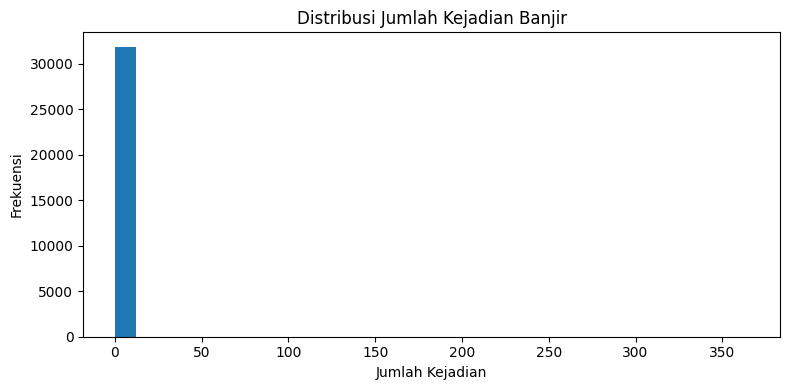

In [7]:
# Visualisasi Distribusi
plt.figure(figsize=(8, 4))
plt.hist(eda_df["jumlah_kejadian"].dropna(), bins=30)
plt.title("Distribusi Jumlah Kejadian Banjir")
plt.xlabel("Jumlah Kejadian")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

,count
tahun,
2019,5312
2020,5312
2021,5312
2022,5312
2023,5311
2024,5311


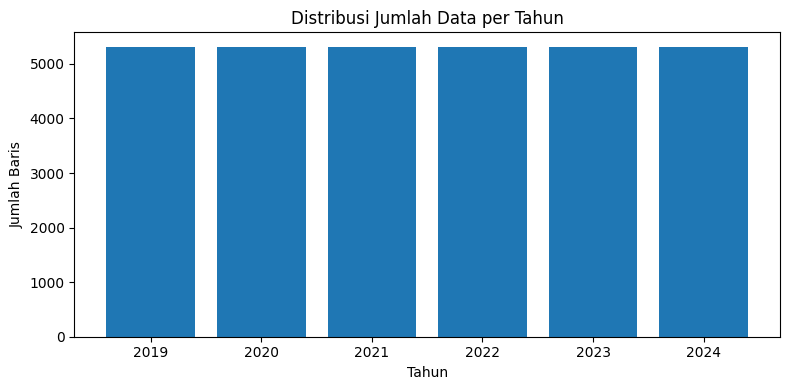

In [8]:
# Visualisasi Distibusi
year_counts = eda_df["tahun"].value_counts().sort_index()

display(year_counts)

plt.figure(figsize=(8, 4))
plt.bar(year_counts.index.astype(int), year_counts.values)
plt.title("Distribusi Jumlah Data per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Baris")
plt.tight_layout()
plt.show()

,bps_nama_kabupaten_kota,jumlah_kejadian
6,KABUPATEN CIREBON,1840
3,KABUPATEN BOGOR,1369
0,KABUPATEN BANDUNG,1078
7,KABUPATEN GARUT,1014
8,KABUPATEN INDRAMAYU,998
9,KABUPATEN KARAWANG,993
2,KABUPATEN BEKASI,881
15,KABUPATEN SUKABUMI,634
14,KABUPATEN SUBANG,545
5,KABUPATEN CIANJUR,432


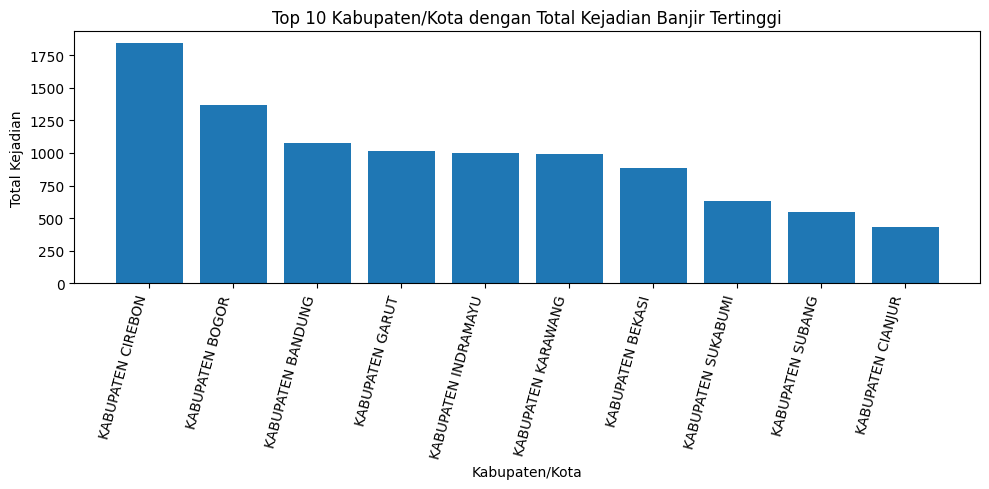

In [9]:
top_kab = (
    eda_df.groupby("bps_nama_kabupaten_kota", as_index=False)["jumlah_kejadian"]
    .sum()
    .sort_values("jumlah_kejadian", ascending=False)
    .head(10)
)

display(top_kab)

plt.figure(figsize=(10, 5))
plt.bar(top_kab["bps_nama_kabupaten_kota"], top_kab["jumlah_kejadian"])
plt.title("Top 10 Kabupaten/Kota dengan Total Kejadian Banjir Tertinggi")
plt.xlabel("Kabupaten/Kota")
plt.ylabel("Total Kejadian")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

**4. EDA- Missing Value**

In [10]:
missing_nonzero = missing_table[missing_table["missing_count"] > 0]
print("Kolom yang memiliki missing value:")
display(missing_nonzero if len(missing_nonzero) > 0 else missing_table.head(0))

Kolom yang memiliki missing value:


,missing_count,missing_pct


**5. EDA- Korelasi**

,kode_provinsi,bps_kode_kabupaten_kota,bps_kode_kecamatan,bps_kode_desa_kelurahan,jumlah_kejadian,tahun,id
kode_provinsi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bps_kode_kabupaten_kota,NaN,1.000000,0.999930,0.999930,0.005557,-0.000090,0.138272
bps_kode_kecamatan,NaN,0.999930,1.000000,1.000000,0.005758,-0.000090,0.138109
bps_kode_desa_kelurahan,NaN,0.999930,1.000000,1.000000,0.005758,-0.000090,0.138109
jumlah_kejadian,NaN,0.005557,0.005758,0.005758,1.000000,-0.006994,-0.006329
tahun,NaN,-0.000090,-0.000090,-0.000090,-0.006994,1.000000,0.986013
id,NaN,0.138272,0.138109,0.138109,-0.006329,0.986013,1.000000


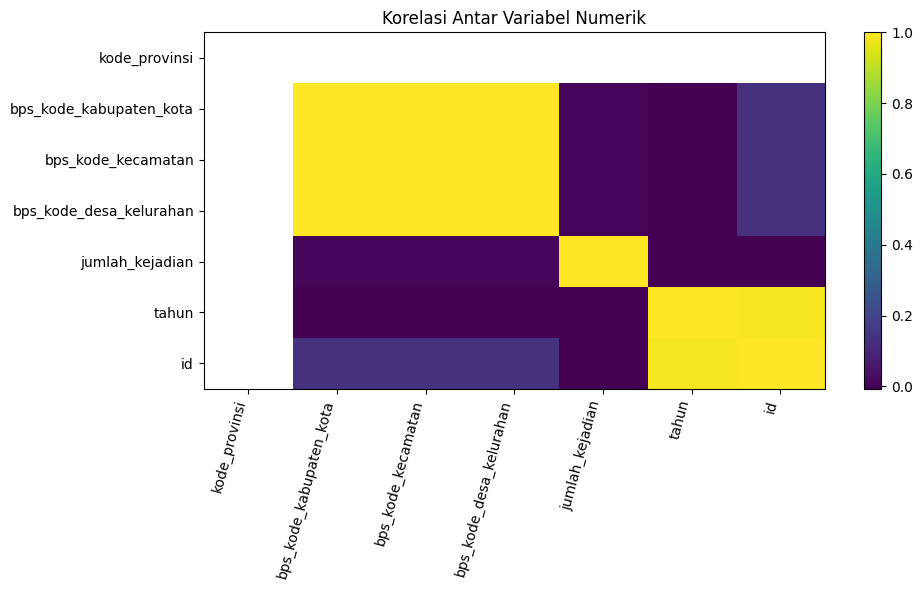

In [11]:
num_df = eda_df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr(numeric_only=True)

display(corr)

plt.figure(figsize=(10, 6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=75, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Korelasi Antar Variabel Numerik")
plt.colorbar()
plt.tight_layout()
plt.show()

**6. Insight Data**

In [12]:
insight_1 = (
    "1. Distribusi jumlah kejadian banjir cenderung terkonsentrasi pada nilai rendah, "
    "yang menunjukkan bahwa sebagian besar observasi memiliki jumlah kejadian kecil."
)

insight_2 = (
    "2. Pemeriksaan missing value menunjukkan kualitas data relatif baik pada kolom utama, "
    "sehingga dataset layak digunakan untuk analisis lanjutan."
)

insight_3 = (
    "3. Total kejadian banjir tidak tersebar merata antar wilayah; terdapat kabupaten/kota tertentu "
    "yang memiliki akumulasi kejadian lebih tinggi dibanding wilayah lain."
)

insight_4 = (
    "4. Distribusi data per tahun dapat digunakan untuk melihat kestabilan ketersediaan data "
    "dan potensi analisis tren sederhana berdasarkan waktu."
)

for text in [insight_1, insight_2, insight_3, insight_4]:
    print(text)

1. Distribusi jumlah kejadian banjir cenderung terkonsentrasi pada nilai rendah, yang menunjukkan bahwa sebagian besar observasi memiliki jumlah kejadian kecil.
2. Pemeriksaan missing value menunjukkan kualitas data relatif baik pada kolom utama, sehingga dataset layak digunakan untuk analisis lanjutan.
3. Total kejadian banjir tidak tersebar merata antar wilayah; terdapat kabupaten/kota tertentu yang memiliki akumulasi kejadian lebih tinggi dibanding wilayah lain.
4. Distribusi data per tahun dapat digunakan untuk melihat kestabilan ketersediaan data dan potensi analisis tren sederhana berdasarkan waktu.


**7. Laporan**

Dataset berhasil dimuat dan dipahami struktur dasarnya.
Pengecekan awal menunjukkan kondisi data dapat dianalisi lebih lanjut.
Distribusi jumlah_kejadian menunjukkan mayoritas observasi berada pada nilai rendah.
Pemeriksaan missing value membantu memastikan kualitas data sebelum tahap prepocessing.
Korelasi antar variabel numerik memberi gambaran hubungan awal antar fitur numerik pada dataset.


**8. Kesimpulan Tahap 2**

Pada tahap 2, data berhasil dikumpulkan dari sumber terbuka, dipahami strukturnya, lalu dianalisis menggunakan pendekatan EDA. Fokus analisis mencakup distribusi data, missing value, dan korelasi. Hasil EDA memberikan pemahaman awal mengenai kualitas data, peresebaran kejadian banjir serta pola umum yang akan menjadi dasar untuk tahap prepocessing dan pembangunan model pada tahap selanjutnya.

**TAHAP 3 (BAGIAN C) - Preprocessing & Feature Engineering**

**1. Data Cleaning**

Tahapannya yaitu mengecek duplikat, missing value, memperbaiki tipe data, merapikan teks kategorikal, memastikan nilai numerik valid dan tidak menimbulkan error saat agregasi.

In [13]:
# salin dataset agar data mentah tetap aman
clean_df = df.copy()

# cek duplikat
print("Jumlah baris duplikat:", clean_df.duplicated().sum())

# cek missing value
missing = clean_df.isna().sum().sort_values(ascending=False)
missing_pct = (clean_df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})
display(missing_table)


Jumlah baris duplikat: 0


,missing_count,missing_pct
kode_provinsi,0,0.0
nama_provinsi,0,0.0
bps_kode_kabupaten_kota,0,0.0
bps_nama_kabupaten_kota,0,0.0
bps_kode_kecamatan,0,0.0
...,...,...
kemendagri_nama_desa_kelurahan,0,0.0
jumlah_kejadian,0,0.0
satuan,0,0.0
tahun,0,0.0


In [14]:
# ubah kolom numerik ke tipe yang sesuai
numeric_cols = [
    "kode_provinsi",
    "bps_kode_kabupaten_kota",
    "bps_kode_kecamatan",
    "bps_kode_desa_kelurahan",
    "jumlah_kejadian",
    "tahun",
    "id",
]

for col in numeric_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# rapikan kolom teks: trim spasi dan ubah ke huruf besar agar konsisten
text_cols = clean_df.select_dtypes(include="object").columns
for col in text_cols:
    clean_df[col] = clean_df[col].astype(str).str.strip().str.upper()

# penanganan missing numerik
clean_df["jumlah_kejadian"] = clean_df["jumlah_kejadian"].fillna(0)
clean_df["tahun"] = clean_df["tahun"].fillna(clean_df["tahun"].median())

# validasi nilai negatif pada jumlah kejadian
neg_count = (clean_df["jumlah_kejadian"] < 0).sum()
print("Jumlah nilai negatif pada jumlah_kejadian:", int(neg_count))
clean_df.loc[clean_df["jumlah_kejadian"] < 0, "jumlah_kejadian"] = 0

print("Shape setelah cleaning dasar:", clean_df.shape)
clean_df.head()


Jumlah nilai negatif pada jumlah_kejadian: 0
Shape setelah cleaning dasar: (31870, 16)


,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,bps_kode_kecamatan,bps_nama_kecamatan,bps_kode_desa_kelurahan,bps_nama_desa_kelurahan,kemendagri_kode_kecamatan,kemendagri_nama_kecamatan,kemendagri_kode_desa_kelurahan,kemendagri_nama_desa_kelurahan,jumlah_kejadian,satuan,tahun,id
0,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190006,WANAHERANG,32.01.02,GUNUNG PUTRI,32.01.02.2001,WANAHERANG,0,KEJADIAN,2019,1
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190010,BOJONG KULUR,32.01.02,GUNUNG PUTRI,32.01.02.2002,BOJONG KULUR,2,KEJADIAN,2019,2
2,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190009,CIANGSANA,32.01.02,GUNUNG PUTRI,32.01.02.2003,CIANGSANA,0,KEJADIAN,2019,3
3,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190002,GUNUNG PUTRI,32.01.02,GUNUNG PUTRI,32.01.02.2004,GUNUNG PUTRI,0,KEJADIAN,2019,4
4,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190004,BOJONG NANGKA,32.01.02,GUNUNG PUTRI,32.01.02.2005,BOJONG NANGKA,1,KEJADIAN,2019,5


**2. Featur Engineering **

Tujuan featur engineering adalah mengubah data mentah level desa/kelirahan menjadi fitur yang lebih informatif untuk model Machine Learning pada level kecamatan.
Fitur yang dibentuk mencakkup:
Frekuensi kejadian banjir, rata-rata dan maksimum kejadian pertahun, variabilitas kejadian antar tahun, cakupan wilayah terdampak, intensitas banjir pada tiap kecamatan.

In [15]:
# fitur indikator dasar
clean_df["pernah_banjir"] = (clean_df["jumlah_kejadian"] > 0).astype(int)

# kategorisasi intensitas kejadian pada level desa/kelurahan
clean_df["kategori_kejadian"] = pd.cut(
    clean_df["jumlah_kejadian"],
    bins=[-0.1, 0, 2, 5, clean_df["jumlah_kejadian"].max()],
    labels=["TIDAK ADA", "RENDAH", "SEDANG", "TINGGI"]
)

clean_df[["jumlah_kejadian", "pernah_banjir", "kategori_kejadian"]].head()


,jumlah_kejadian,pernah_banjir,kategori_kejadian
0,0,0,TIDAK ADA
1,2,1,RENDAH
2,0,0,TIDAK ADA
3,0,0,TIDAK ADA
4,1,1,RENDAH


In [16]:
# agregasi ke level kecamatan per tahun
kec_tahun = (
    clean_df.groupby(
        [
            "bps_nama_kabupaten_kota",
            "bps_nama_kecamatan",
            "tahun"
        ],
        as_index=False
    )
    .agg(
        total_kejadian_tahun=("jumlah_kejadian", "sum"),
        desa_terdampak_tahun=("pernah_banjir", "sum"),
        jumlah_desa_tercatat=("bps_nama_desa_kelurahan", "nunique")
    )
)

kec_tahun.head()


,bps_nama_kabupaten_kota,bps_nama_kecamatan,tahun,total_kejadian_tahun,desa_terdampak_tahun,jumlah_desa_tercatat
0,KABUPATEN BANDUNG,ARJASARI,2019,0,0,11
1,KABUPATEN BANDUNG,ARJASARI,2020,0,0,11
2,KABUPATEN BANDUNG,ARJASARI,2021,1,1,11
3,KABUPATEN BANDUNG,ARJASARI,2022,2,2,11
4,KABUPATEN BANDUNG,ARJASARI,2023,8,3,11


In [17]:
# agregasi final level kecamatan untuk data modeling
fitur_kecamatan = (
    kec_tahun.groupby(
        ["bps_nama_kabupaten_kota", "bps_nama_kecamatan"],
        as_index=False
    )
    .agg(
        total_kejadian_2019_2024=("total_kejadian_tahun", "sum"),
        rata_rata_kejadian_tahunan=("total_kejadian_tahun", "mean"),
        maksimum_kejadian_1_tahun=("total_kejadian_tahun", "max"),
        minimum_kejadian_1_tahun=("total_kejadian_tahun", "min"),
        std_kejadian_tahunan=("total_kejadian_tahun", "std"),
        total_desa_terdampak=("desa_terdampak_tahun", "sum"),
        rata_rata_desa_terdampak=("desa_terdampak_tahun", "mean"),
        jumlah_tahun_tercatat=("tahun", "nunique"),
        rata_rata_jumlah_desa=("jumlah_desa_tercatat", "mean")
    )
)

# isi std yang kosong dengan 0 (biasanya terjadi jika observasi hanya 1 nilai unik)
fitur_kecamatan["std_kejadian_tahunan"] = fitur_kecamatan["std_kejadian_tahunan"].fillna(0)

# fitur turunan tambahan
fitur_kecamatan["range_kejadian_tahunan"] = (
    fitur_kecamatan["maksimum_kejadian_1_tahun"] - fitur_kecamatan["minimum_kejadian_1_tahun"]
)

fitur_kecamatan["proporsi_desa_terdampak"] = (
    fitur_kecamatan["rata_rata_desa_terdampak"] / fitur_kecamatan["rata_rata_jumlah_desa"]
)

fitur_kecamatan["intensitas_banjir"] = (
    fitur_kecamatan["total_kejadian_2019_2024"] / fitur_kecamatan["jumlah_tahun_tercatat"]
)

fitur_kecamatan.head()


,bps_nama_kabupaten_kota,bps_nama_kecamatan,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun,minimum_kejadian_1_tahun,std_kejadian_tahunan,total_desa_terdampak,rata_rata_desa_terdampak,jumlah_tahun_tercatat,rata_rata_jumlah_desa,range_kejadian_tahunan,proporsi_desa_terdampak,intensitas_banjir
0,KABUPATEN BANDUNG,ARJASARI,19,3.166667,8,0,3.816630,9,1.500000,6,11.0,8,0.136364,3.166667
1,KABUPATEN BANDUNG,BALEENDAH,18,3.000000,3,3,0.000000,12,2.000000,6,3.0,0,0.666667,3.000000
2,KABUPATEN BANDUNG,BANJARAN,63,10.500000,17,5,4.086563,27,4.500000,6,11.0,12,0.409091,10.500000
3,KABUPATEN BANDUNG,BOJONGSOANG,46,7.666667,11,4,2.658320,22,3.666667,6,6.0,7,0.611111,7.666667
4,KABUPATEN BANDUNG,CANGKUANG,20,3.333333,5,0,2.581989,4,0.666667,6,7.0,5,0.095238,3.333333


**3. Penjelasan Fitur yang digunakan**

Fitur yang dipakai untuk modelling dipilih karena mewakili 4 aspek utama yaitu:

Frekuensi banjir, intensitas kejadian, kestabilan/variasi kejadian antar tahun, cakupan dampak pada desa/kelurahan dalam satu kecamatan.

In [18]:
kamus_fitur = pd.DataFrame({
    "fitur": [
        "total_kejadian_2019_2024",
        "rata_rata_kejadian_tahunan",
        "maksimum_kejadian_1_tahun",
        "std_kejadian_tahunan",
        "range_kejadian_tahunan",
        "total_desa_terdampak",
        "proporsi_desa_terdampak",
        "intensitas_banjir",
    ],
    "penjelasan": [
        "Total seluruh kejadian banjir per kecamatan selama periode data.",
        "Rata-rata kejadian banjir per tahun pada tiap kecamatan.",
        "Nilai kejadian tertinggi dalam satu tahun.",
        "Menggambarkan kestabilan atau fluktuasi kejadian tiap tahun.",
        "Selisih antara kejadian maksimum dan minimum per tahun.",
        "Akumulasi desa/kelurahan yang terdampak banjir.",
        "Rasio rata-rata desa terdampak terhadap total desa tercatat.",
        "Ukuran intensitas banjir per tahun pada tiap kecamatan."
    ]
})

display(kamus_fitur)


,fitur,penjelasan
0,total_kejadian_2019_2024,Total seluruh kejadian banjir per kecamatan se...
1,rata_rata_kejadian_tahunan,Rata-rata kejadian banjir per tahun pada tiap ...
2,maksimum_kejadian_1_tahun,Nilai kejadian tertinggi dalam satu tahun.
3,std_kejadian_tahunan,Menggambarkan kestabilan atau fluktuasi kejadi...
4,range_kejadian_tahunan,Selisih antara kejadian maksimum dan minimum p...
5,total_desa_terdampak,Akumulasi desa/kelurahan yang terdampak banjir.
6,proporsi_desa_terdampak,Rasio rata-rata desa terdampak terhadap total ...
7,intensitas_banjir,Ukuran intensitas banjir per tahun pada tiap k...


**4. Seleksi fitur penting**

Pillih fitur numerik yang akan dimasukkan ke dataset final

In [19]:
# Feature selection
feature_cols = [
    "total_kejadian_2019_2024",
    "rata_rata_kejadian_tahunan",
    "maksimum_kejadian_1_tahun",
    "std_kejadian_tahunan",
    "range_kejadian_tahunan",
    "total_desa_terdampak",
    "proporsi_desa_terdampak",
    "intensitas_banjir",
]

final_dataset = fitur_kecamatan[[
    "bps_nama_kabupaten_kota",
    "bps_nama_kecamatan",
    *feature_cols
]].copy()

print("Shape dataset final:", final_dataset.shape)
display(final_dataset.head())


Shape dataset final: (539, 10)


,bps_nama_kabupaten_kota,bps_nama_kecamatan,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun,std_kejadian_tahunan,range_kejadian_tahunan,total_desa_terdampak,proporsi_desa_terdampak,intensitas_banjir
0,KABUPATEN BANDUNG,ARJASARI,19,3.166667,8,3.816630,8,9,0.136364,3.166667
1,KABUPATEN BANDUNG,BALEENDAH,18,3.000000,3,0.000000,0,12,0.666667,3.000000
2,KABUPATEN BANDUNG,BANJARAN,63,10.500000,17,4.086563,12,27,0.409091,10.500000
3,KABUPATEN BANDUNG,BOJONGSOANG,46,7.666667,11,2.658320,7,22,0.611111,7.666667
4,KABUPATEN BANDUNG,CANGKUANG,20,3.333333,5,2.581989,5,4,0.095238,3.333333


In [20]:
# cek missing value dataset final
print("Missing value dataset final:")
display(final_dataset.isna().sum())

# statistik deskriptif fitur numerik
final_dataset[feature_cols].describe().T


Missing value dataset final:


,0
bps_nama_kabupaten_kota,0
bps_nama_kecamatan,0
total_kejadian_2019_2024,0
rata_rata_kejadian_tahunan,0
maksimum_kejadian_1_tahun,0
std_kejadian_tahunan,0
range_kejadian_tahunan,0
total_desa_terdampak,0
proporsi_desa_terdampak,0
intensitas_banjir,0


,count,mean,std,min,25%,50%,75%,max
total_kejadian_2019_2024,539.0,21.990724,39.842696,0.0,2.000000,11.000000,27.000000,443.000000
rata_rata_kejadian_tahunan,539.0,3.665121,6.640449,0.0,0.333333,1.833333,4.500000,73.833333
maksimum_kejadian_1_tahun,539.0,6.309833,18.299210,0.0,1.000000,3.000000,7.000000,374.000000
std_kejadian_tahunan,539.0,1.903975,7.035072,0.0,0.408248,0.983192,1.953587,147.161702
range_kejadian_tahunan,539.0,4.526902,16.987660,0.0,1.000000,2.000000,5.000000,365.000000
total_desa_terdampak,539.0,13.018553,14.061589,0.0,2.000000,8.000000,20.000000,64.000000
proporsi_desa_terdampak,539.0,0.228362,0.242010,0.0,0.033333,0.148148,0.347222,1.000000
intensitas_banjir,539.0,3.665121,6.640449,0.0,0.333333,1.833333,4.500000,73.833333


,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun,std_kejadian_tahunan,range_kejadian_tahunan,total_desa_terdampak,proporsi_desa_terdampak,intensitas_banjir
total_kejadian_2019_2024,1.000000,1.000000,0.827106,0.739758,0.721080,0.677710,0.614240,1.000000
rata_rata_kejadian_tahunan,1.000000,1.000000,0.827106,0.739758,0.721080,0.677710,0.614240,1.000000
maksimum_kejadian_1_tahun,0.827106,0.827106,1.000000,0.980324,0.981906,0.404901,0.348185,0.827106
std_kejadian_tahunan,0.739758,0.739758,0.980324,1.000000,0.997022,0.274333,0.228569,0.739758
range_kejadian_tahunan,0.721080,0.721080,0.981906,0.997022,1.000000,0.275649,0.226883,0.721080
total_desa_terdampak,0.677710,0.677710,0.404901,0.274333,0.275649,1.000000,0.920682,0.677710
proporsi_desa_terdampak,0.614240,0.614240,0.348185,0.228569,0.226883,0.920682,1.000000,0.614240
intensitas_banjir,1.000000,1.000000,0.827106,0.739758,0.721080,0.677710,0.614240,1.000000


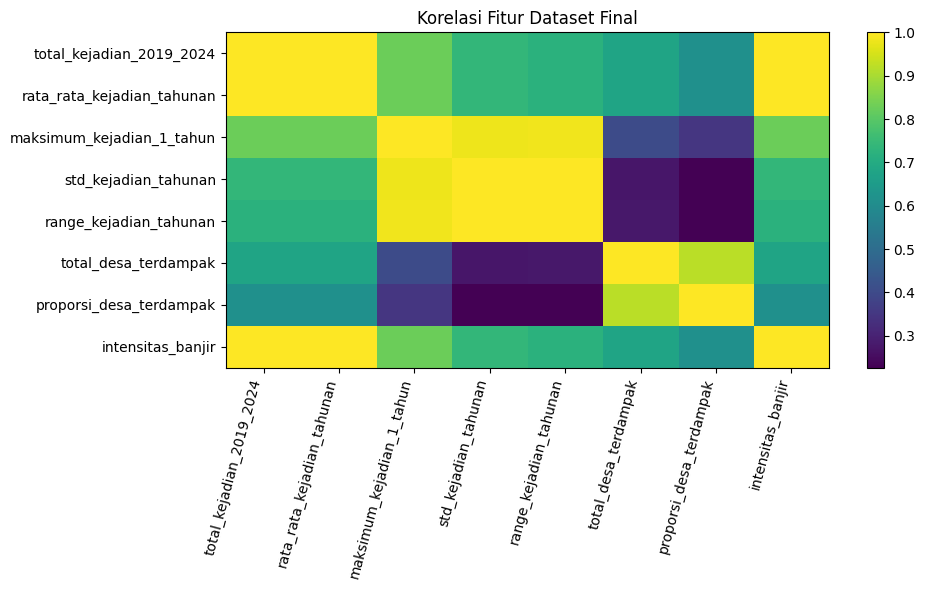

In [21]:
# korelasi antar fitur untuk melihat apakah fitur cukup informatif
corr = final_dataset[feature_cols].corr()
display(corr)

plt.figure(figsize=(10, 6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=75, ha="right")
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Korelasi Fitur Dataset Final")
plt.colorbar()
plt.tight_layout()
plt.show()


**5. Simpan Dataset Final**

In [22]:
OUTPUT_PATH = "dataset_final_banjir.csv"
final_dataset.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset final berhasil disimpan ke: {OUTPUT_PATH}")


Dataset final berhasil disimpan ke: dataset_final_banjir.csv


In [23]:
from google.colab import files
files.download("dataset_final_banjir.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**6. Kesimpulan Tahap 3**

Tahap prepocessing telah berhasil dilakukan dengan:
pembersihan data, validasi tipe data, pembentukkan fitur baru, seleksi fitur penting, dan penyusunan datset final level kecamatan.

Hasil akhirnya adalah dataset lebih bersih, lebih terstruktur dan siap digunakan pada tahap selanjutnya.






**TAHAP 4 (BAGIAN D) - Pembangunan Model Machine Learning**

Tahap ini dilakukan pembangunan model machine learning untuk mengelompokkan wiilayah rawan banjir di jawa barat berdasrkan dataset hasil tahap 3.

Algoritma yanng digunakan K-Means Clustering dan Agglomerative Clustering.

**1. Load Dataset Final**

In [24]:
# Gunakan dataset final hasil Tahap 3
candidate_files = [
    "dataset_final_banjir.csv"
]

dataset_path = None
for file_name in candidate_files:
    if Path(file_name).exists():
        dataset_path = file_name
        break

if dataset_path is None:
    raise FileNotFoundError(
        "Dataset final tidak ditemukan. Jalankan Tahap 3 terlebih dahulu atau pastikan file CSV ada di folder kerja."
    )

df_model = pd.read_csv(dataset_path)
print("Dataset yang dipakai:", dataset_path)
df_model.head()

Dataset yang dipakai: dataset_final_banjir.csv


,bps_nama_kabupaten_kota,bps_nama_kecamatan,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun,std_kejadian_tahunan,range_kejadian_tahunan,total_desa_terdampak,proporsi_desa_terdampak,intensitas_banjir
0,KABUPATEN BANDUNG,ARJASARI,19,3.166667,8,3.816630,8,9,0.136364,3.166667
1,KABUPATEN BANDUNG,BALEENDAH,18,3.000000,3,0.000000,0,12,0.666667,3.000000
2,KABUPATEN BANDUNG,BANJARAN,63,10.500000,17,4.086563,12,27,0.409091,10.500000
3,KABUPATEN BANDUNG,BOJONGSOANG,46,7.666667,11,2.658320,7,22,0.611111,7.666667
4,KABUPATEN BANDUNG,CANGKUANG,20,3.333333,5,2.581989,5,4,0.095238,3.333333


**2. Cek Struktur Datasetnya**






In [25]:
print("Shape dataset:", df.shape)
df.info()

Shape dataset: (31870, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31870 entries, 0 to 31869
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   kode_provinsi                   31870 non-null  int64 
 1   nama_provinsi                   31870 non-null  object
 2   bps_kode_kabupaten_kota         31870 non-null  int64 
 3   bps_nama_kabupaten_kota         31870 non-null  object
 4   bps_kode_kecamatan              31870 non-null  int64 
 5   bps_nama_kecamatan              31870 non-null  object
 6   bps_kode_desa_kelurahan         31870 non-null  int64 
 7   bps_nama_desa_kelurahan         31870 non-null  object
 8   kemendagri_kode_kecamatan       31870 non-null  object
 9   kemendagri_nama_kecamatan       31870 non-null  object
 10  kemendagri_kode_desa_kelurahan  31870 non-null  object
 11  kemendagri_nama_desa_kelurahan  31870 non-null  object
 12  jumlah_kejadian    

**3. Fitur yang Digunakan untuk Model**

Model clustering hanya menggunakan fitur numerik hasil feature engineering.

(1) total_kejadian_2019_2024: total kejadian banjir selama periode 2019-2024

(2) rata_rata_kejadian_tahunan: rata-rata kejadian banjir per tahun

(3) maksimum_kejadian_1_tahun: jumlah kejadian banjir tertinggi dalam satu tahun

Ketiga fitur ini merepresentasikan tingkat kerawanan banjir tiap kecmatan.





In [26]:
feature_cols = ["total_kejadian_2019_2024", "rata_rata_kejadian_tahunan", "maksimum_kejadian_1_tahun"]
X_raw = df_model[feature_cols].copy()

X_raw.head()

,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun
0,19,3.166667,8
1,18,3.000000,3
2,63,10.500000,17
3,46,7.666667,11
4,20,3.333333,5


**4. Alasan Pemilihan Algoritma**

(1) K-Means Clustering dipilih karena
*   Sederhana dan efisien
*   Cocok untuk data numerik
*   Sering digunakan untuk segmentasi atau pengelompokkan data


(2) Agglomerative Clustering dipilih karena
*   Dapat melihat pengelompokkan secara hierarkis
*   Tidak bergantung pada centroid
*   Relevan untuk membandingkan hasil clustering terhadap K-Means


(3) DBSCAN
*   Dapat mendeteksi noise atau outlier
*   Tidak mewajibkan seluruh data masuk ke cluster
*   Relevan untuk kasus wilayah ekstrem yang sangat berbeda dari mayoritas












**5. Normalisasi Data **

Normalisasi dilakukan agar seluruh fitur berada pada skala yang sebanding sebelum proses clustering.

Note metodologi:

Pada clustering, train-test split tidak digunakan seperti pada supervised learning, karena tujuan model adalah menemukan pola kemiripan pd seluruh data. Oleh karena itu seluruh data kecematan digunakan dalam proses clustering.

In [27]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

pd.DataFrame(X, columns=feature_cols).head()

,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun
0,-0.075133,-0.075133,0.092449
1,-0.100255,-0.100255,-0.181041
2,1.030236,1.030236,0.584730
3,0.603161,0.603161,0.256542
4,-0.050011,-0.050011,-0.071645


**6. Menentukan Jumlah Cluster dengan Elbow Method**

Elbow Method digunakan untuk membantu memilih jumlah cluster yang wajar untuk model K-Means

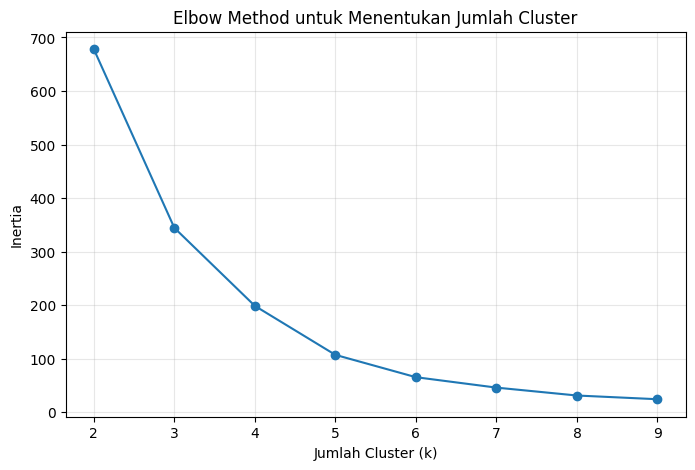

In [28]:
inertia = []
k_values = range(2, 10)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia, marker="o")
plt.title("Elbow Method untuk Menentukan Jumlah Cluster")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.3)
plt.show()

Berdasarkan grafik elbow, jumlah clluster yang dipilih adalah 3 cluster karena penurunan inertia mulai melandai setelah titik itu. Pemilihan 3 cluster juga memudahkan interpretasi wilayah mendaji rendah, sedanng dan tinggi.

**Model 1 - K-Means Clustering**

In [29]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model["cluster_kmeans"] = kmeans.fit_predict(X)

score_kmeans = silhouette_score(X, df_model["cluster_kmeans"])

print("Silhouette Score K-Means:", round(score_kmeans, 4))
df.head()

Silhouette Score K-Means: 0.7109


,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,bps_kode_kecamatan,bps_nama_kecamatan,bps_kode_desa_kelurahan,bps_nama_desa_kelurahan,kemendagri_kode_kecamatan,kemendagri_nama_kecamatan,kemendagri_kode_desa_kelurahan,kemendagri_nama_desa_kelurahan,jumlah_kejadian,satuan,tahun,id
0,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190006,WANAHERANG,32.01.02,GUNUNG PUTRI,32.01.02.2001,WANAHERANG,0,KEJADIAN,2019,1
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190010,BOJONG KULUR,32.01.02,GUNUNG PUTRI,32.01.02.2002,BOJONG KULUR,2,KEJADIAN,2019,2
2,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190009,CIANGSANA,32.01.02,GUNUNG PUTRI,32.01.02.2003,CIANGSANA,0,KEJADIAN,2019,3
3,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190002,GUNUNG PUTRI,32.01.02,GUNUNG PUTRI,32.01.02.2004,GUNUNG PUTRI,0,KEJADIAN,2019,4
4,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201190,GUNUNG PUTRI,3201190004,BOJONG NANGKA,32.01.02,GUNUNG PUTRI,32.01.02.2005,BOJONG NANGKA,1,KEJADIAN,2019,5


In [54]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_kmeans = silhouette_score(X, df_model["cluster_kmeans"])
dbi_kmeans = davies_bouldin_score(X, df_model["cluster_kmeans"])

print("Silhouette Score K-Means :", round(sil_kmeans, 4))
print("Davies-Bouldin Score K-Means :", round(dbi_kmeans, 4))

Silhouette Score K-Means : 0.7109
Davies-Bouldin Score K-Means : 0.5157


**Hasil Training K-Means**

In [30]:
kmeans_summary = df_model.groupby("cluster_kmeans")[feature_cols].mean().round(2)
kmeans_count = df_model["cluster_kmeans"].value_counts().sort_index()

print("Jumlah anggota tiap cluster (K-Means):")
print(kmeans_count)
print("\nRata-rata fitur tiap cluster (K-Means):")
display(kmeans_summary)

Jumlah anggota tiap cluster (K-Means):
cluster_kmeans
0     84
1      3
2    452
Name: count, dtype: int64

Rata-rata fitur tiap cluster (K-Means):


,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun
cluster_kmeans,,,
0,68.49,11.41,16.12
1,418.67,69.78,200.33
2,10.72,1.79,3.20


In [72]:
# Urutkan cluster berdasarkan tingkat risiko
urutan_cluster = (
    kmeans_summary["total_kejadian_2019_2024"]
    .sort_values()
    .index
    .tolist()
)

# Remap cluster menjadi 0,1,2 sesuai urutan risiko
cluster_map = {
    urutan_cluster[0]: 0,  # Rendah
    urutan_cluster[1]: 1,  # Sedang
    urutan_cluster[2]: 2   # Tinggi
}

df_model["cluster_kmeans"] = df_model["cluster_kmeans"].map(cluster_map)

# Mapping label
label_map = {
    0: "Rendah",
    1: "Sedang",
    2: "Tinggi"
}

df_model["label_kmeans"] = df_model["cluster_kmeans"].map(label_map)

# Tampilkan hasil
print(df_model[[
    "bps_nama_kabupaten_kota",
    "bps_nama_kecamatan",
    "cluster_kmeans",
    "label_kmeans"
]].head(10))

  bps_nama_kabupaten_kota bps_nama_kecamatan  cluster_kmeans label_kmeans
0       KABUPATEN BANDUNG           ARJASARI               1       Sedang
1       KABUPATEN BANDUNG          BALEENDAH               1       Sedang
2       KABUPATEN BANDUNG           BANJARAN               2       Tinggi
3       KABUPATEN BANDUNG        BOJONGSOANG               2       Tinggi
4       KABUPATEN BANDUNG          CANGKUANG               1       Sedang
5       KABUPATEN BANDUNG         CICALENGKA               1       Sedang
6       KABUPATEN BANDUNG          CIKANCUNG               1       Sedang
7       KABUPATEN BANDUNG        CILENGKRANG               1       Sedang
8       KABUPATEN BANDUNG           CILEUNYI               2       Tinggi
9       KABUPATEN BANDUNG            CIMAUNG               1       Sedang


**Model 2 - Agglomerative Clustering**



In [32]:
agg = AgglomerativeClustering(n_clusters=3)
df_model["cluster_agg"] = agg.fit_predict(X)

score_agg = silhouette_score(X, df_model["cluster_agg"])

print("Silhouette Score Agglomerative:", round(score_agg, 4))
df_model.head()

Silhouette Score Agglomerative: 0.6782


,bps_nama_kabupaten_kota,bps_nama_kecamatan,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun,std_kejadian_tahunan,range_kejadian_tahunan,total_desa_terdampak,proporsi_desa_terdampak,intensitas_banjir,cluster_kmeans,label_kmeans,cluster_agg
0,KABUPATEN BANDUNG,ARJASARI,19,3.166667,8,3.816630,8,9,0.136364,3.166667,2,Rendah,2
1,KABUPATEN BANDUNG,BALEENDAH,18,3.000000,3,0.000000,0,12,0.666667,3.000000,2,Rendah,2
2,KABUPATEN BANDUNG,BANJARAN,63,10.500000,17,4.086563,12,27,0.409091,10.500000,0,Sedang,1
3,KABUPATEN BANDUNG,BOJONGSOANG,46,7.666667,11,2.658320,7,22,0.611111,7.666667,0,Sedang,1
4,KABUPATEN BANDUNG,CANGKUANG,20,3.333333,5,2.581989,5,4,0.095238,3.333333,2,Rendah,2


In [62]:
from sklearn.metrics import davies_bouldin_score

dbi_agg = davies_bouldin_score(X, df_model["cluster_agg"])

print("Silhouette Score Agglomerative :", round(score_agg, 4))
print("Davies-Bouldin Score Agglomerative :", round(dbi_agg, 4))

Silhouette Score Agglomerative : 0.6782
Davies-Bouldin Score Agglomerative : 0.5389


**Hasil Training Agglomerativ**e

In [63]:
agg_summary = df_model.groupby("cluster_agg")[feature_cols].mean().round(2)
agg_count = df_model["cluster_agg"].value_counts().sort_index()

print("Jumlah anggota tiap cluster (Agglomerative):")
print(agg_count)
print("\nRata-rata fitur tiap cluster (Agglomerative):")
display(agg_summary)

Jumlah anggota tiap cluster (Agglomerative):
cluster_agg
0      3
1    128
2    408
Name: count, dtype: int64

Rata-rata fitur tiap cluster (Agglomerative):


,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun
cluster_agg,,,
0,418.67,69.78,200.33
1,56.46,9.41,13.71
2,8.26,1.38,2.56


In [73]:
# Urutkan cluster berdasarkan rata-rata total kejadian banjir
urutan_agg = (
    agg_summary["total_kejadian_2019_2024"]
    .sort_values()
    .index
    .tolist()
)

# Remap cluster menjadi 0,1,2 sesuai tingkat risiko
cluster_map_agg = {
    urutan_agg[0]: 0,  # Rendah
    urutan_agg[1]: 1,  # Sedang
    urutan_agg[2]: 2   # Tinggi
}

df_model["cluster_agg"] = df_model["cluster_agg"].map(cluster_map_agg)

# Mapping label
label_map_agg = {
    0: "Rendah",
    1: "Sedang",
    2: "Tinggi"
}

df_model["label_agg"] = df_model["cluster_agg"].map(label_map_agg)

print("Mapping label Agglomerative:")
print(label_map_agg)

# Tampilkan hasil
print(df_model[[
    "bps_nama_kabupaten_kota",
    "bps_nama_kecamatan",
    "total_kejadian_2019_2024",
    "cluster_agg",
    "label_agg"
]].head(10))

Mapping label Agglomerative:
{0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}
  bps_nama_kabupaten_kota bps_nama_kecamatan  total_kejadian_2019_2024  \
0       KABUPATEN BANDUNG           ARJASARI                        19   
1       KABUPATEN BANDUNG          BALEENDAH                        18   
2       KABUPATEN BANDUNG           BANJARAN                        63   
3       KABUPATEN BANDUNG        BOJONGSOANG                        46   
4       KABUPATEN BANDUNG          CANGKUANG                        20   
5       KABUPATEN BANDUNG         CICALENGKA                        30   
6       KABUPATEN BANDUNG          CIKANCUNG                        38   
7       KABUPATEN BANDUNG        CILENGKRANG                         5   
8       KABUPATEN BANDUNG           CILEUNYI                        50   
9       KABUPATEN BANDUNG            CIMAUNG                         0   

   cluster_agg label_agg  
0            0    Rendah  
1            0    Rendah  
2            1    Sedang  
3       

**Model 3 - DBSCAN**

DBSCAN tidak membutuhkan jumlah cluster sejak awall. Karena itu dilakukan pencarian beberapa kombinasi eps dan min_samples, lalu dipilih parameter dengan hasil cluster yang valid dan nilai silhourtte terbaik pada data non-noise.

In [65]:
dbscan_candidates = []

for eps in np.arange(0.20, 1.05, 0.05):
    for min_samples in [3, 4, 5, 6, 8]:
        model = DBSCAN(eps=float(np.round(eps, 2)), min_samples=min_samples)
        labels = model.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        mask = labels != -1

        if n_clusters >= 2 and mask.sum() > n_clusters:
            sil = silhouette_score(X[mask], labels[mask])
            dbscan_candidates.append({
                "eps": float(np.round(eps, 2)),
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "n_noise": n_noise,
                "silhouette_score": sil
            })

dbscan_tuning = pd.DataFrame(dbscan_candidates).sort_values(
    ["silhouette_score", "n_noise"],
    ascending=[False, True]
).reset_index(drop=True)

if dbscan_tuning.empty:
    raise ValueError("DBSCAN tidak menemukan kombinasi parameter yang menghasilkan minimal 2 cluster yang valid.")

display(dbscan_tuning.head(10))

,eps,min_samples,n_clusters,n_noise,silhouette_score
0,0.60,3,2,5,0.787999
1,0.65,3,2,5,0.787999
2,0.20,3,2,16,0.768322
3,0.25,3,2,15,0.765575
4,0.30,3,2,13,0.764943
5,0.35,4,2,12,0.759162
6,0.40,4,2,12,0.759162
7,0.45,4,2,8,0.745770
8,0.35,3,3,9,0.679030
9,0.40,3,3,9,0.679030


In [74]:
best_dbscan = dbscan_tuning.iloc[0]
best_eps = float(best_dbscan["eps"])
best_min_samples = int(best_dbscan["min_samples"])

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df_model["cluster_dbscan"] = dbscan.fit_predict(X)

mask_dbscan = df_model["cluster_dbscan"] != -1
n_clusters_dbscan = df_model["cluster_dbscan"].nunique() - (1 if -1 in df_model["cluster_dbscan"].unique() else 0)
noise_count = int((df_model["cluster_dbscan"] == -1).sum())

if mask_dbscan.sum() > n_clusters_dbscan and n_clusters_dbscan >= 2:
    score_dbscan = silhouette_score(X[mask_dbscan], df_model.loc[mask_dbscan, "cluster_dbscan"])
else:
    score_dbscan = np.nan

print(f"Parameter DBSCAN terbaik: eps={best_eps}, min_samples={best_min_samples}")
print(f"Jumlah cluster DBSCAN (tanpa noise): {n_clusters_dbscan}")
print(f"Jumlah data noise / outlier: {noise_count}")
print("Silhouette Score DBSCAN:", round(score_dbscan, 4) if pd.notna(score_dbscan) else "Tidak tersedia")

df_model.head()

Parameter DBSCAN terbaik: eps=0.6, min_samples=3
Jumlah cluster DBSCAN (tanpa noise): 2
Jumlah data noise / outlier: 5
Silhouette Score DBSCAN: 0.788


,bps_nama_kabupaten_kota,bps_nama_kecamatan,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun,std_kejadian_tahunan,range_kejadian_tahunan,total_desa_terdampak,proporsi_desa_terdampak,intensitas_banjir,cluster_kmeans,label_kmeans,cluster_agg,label_agg,cluster_dbscan,label_dbscan,cluster_kmeans_final
0,KABUPATEN BANDUNG,ARJASARI,19,3.166667,8,3.816630,8,9,0.136364,3.166667,1,Sedang,0,Rendah,0,Rendah,0
1,KABUPATEN BANDUNG,BALEENDAH,18,3.000000,3,0.000000,0,12,0.666667,3.000000,1,Sedang,0,Rendah,0,Rendah,0
2,KABUPATEN BANDUNG,BANJARAN,63,10.500000,17,4.086563,12,27,0.409091,10.500000,2,Tinggi,1,Sedang,0,Rendah,1
3,KABUPATEN BANDUNG,BOJONGSOANG,46,7.666667,11,2.658320,7,22,0.611111,7.666667,2,Tinggi,1,Sedang,0,Rendah,1
4,KABUPATEN BANDUNG,CANGKUANG,20,3.333333,5,2.581989,5,4,0.095238,3.333333,1,Sedang,0,Rendah,0,Rendah,0


In [66]:
from sklearn.metrics import davies_bouldin_score

if mask_dbscan.sum() > n_clusters_dbscan and n_clusters_dbscan >= 2:
    score_dbscan = silhouette_score(
        X[mask_dbscan],
        df_model.loc[mask_dbscan, "cluster_dbscan"]
    )

    dbi_dbscan = davies_bouldin_score(
        X[mask_dbscan],
        df_model.loc[mask_dbscan, "cluster_dbscan"]
    )
else:
    score_dbscan = np.nan
    dbi_dbscan = np.nan

print(f"Parameter DBSCAN terbaik: eps={best_eps}, min_samples={best_min_samples}")
print(f"Jumlah cluster DBSCAN (tanpa noise): {n_clusters_dbscan}")
print(f"Jumlah data noise / outlier: {noise_count}")
print("Silhouette Score DBSCAN:", round(score_dbscan, 4))
print("Davies-Bouldin Score DBSCAN:", round(dbi_dbscan, 4))

Parameter DBSCAN terbaik: eps=0.6, min_samples=3
Jumlah cluster DBSCAN (tanpa noise): 2
Jumlah data noise / outlier: 5
Silhouette Score DBSCAN: 0.788
Davies-Bouldin Score DBSCAN: 0.2154


**Hasil Training DBSCAN**

In [37]:
# Hasil training
dbscan_count = df_model["cluster_dbscan"].value_counts().sort_index()
dbscan_summary = df_model.loc[df_model["cluster_dbscan"] != -1].groupby("cluster_dbscan")[feature_cols].mean().round(2)

print("Jumlah anggota tiap cluster (DBSCAN):")
print(dbscan_count)

print("\nRata-rata fitur tiap cluster (DBSCAN, tanpa noise):")
display(dbscan_summary)

Jumlah anggota tiap cluster (DBSCAN):
cluster_dbscan
-1      5
 0    531
 1      3
Name: count, dtype: int64

Rata-rata fitur tiap cluster (DBSCAN, tanpa noise):


,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun
cluster_dbscan,,,
0,18.38,3.06,4.88
1,139.33,23.22,37.33


In [75]:
# Mapping label DBSCAN
if not dbscan_summary.empty and len(dbscan_summary.index) >= 2:
    urutan_dbscan = dbscan_summary["total_kejadian_2019_2024"].sort_values().index.tolist()
    level_names = ["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]
    label_map_dbscan = {cluster_id: level_names[i] for i, cluster_id in enumerate(urutan_dbscan)}
    df_model["label_dbscan"] = df_model["cluster_dbscan"].map(label_map_dbscan)
    df_model.loc[df_model["cluster_dbscan"] == -1, "label_dbscan"] = "Noise/Outlier"
else:
    label_map_dbscan = {}
    df_model["label_dbscan"] = np.where(df_model["cluster_dbscan"] == -1, "Noise/Outlier", "Cluster")

print("Mapping label DBSCAN:")
print(label_map_dbscan)

df_model[[
    "bps_nama_kabupaten_kota",
    "bps_nama_kecamatan",
    "cluster_dbscan",
    "label_dbscan"
]].head(20)

Mapping label DBSCAN:
{0: 'Rendah', 1: 'Sedang'}


,bps_nama_kabupaten_kota,bps_nama_kecamatan,cluster_dbscan,label_dbscan
0,KABUPATEN BANDUNG,ARJASARI,0,Rendah
1,KABUPATEN BANDUNG,BALEENDAH,0,Rendah
2,KABUPATEN BANDUNG,BANJARAN,0,Rendah
3,KABUPATEN BANDUNG,BOJONGSOANG,0,Rendah
4,KABUPATEN BANDUNG,CANGKUANG,0,Rendah
...,...,...,...,...
15,KABUPATEN BANDUNG,KATAPANG,0,Rendah
16,KABUPATEN BANDUNG,KERTASARI,0,Rendah
17,KABUPATEN BANDUNG,KUTAWARINGIN,0,Rendah
18,KABUPATEN BANDUNG,MAJALAYA,0,Rendah


**7. Evaluasi dan Perbandingan Model**



In [69]:
from sklearn.metrics import davies_bouldin_score

dbi_kmeans = davies_bouldin_score(X, df_model["cluster_kmeans"])
dbi_agg = davies_bouldin_score(X, df_model["cluster_agg"])

dbi_dbscan = davies_bouldin_score(
    X[mask_dbscan],
    df_model.loc[mask_dbscan, "cluster_dbscan"]
)

In [70]:
comparison = pd.DataFrame({
    "Algoritma": ["K-Means", "Agglomerative", "DBSCAN"],
    "Silhouette Score": [score_kmeans, score_agg, score_dbscan],
    "Davies-Bouldin Score": [dbi_kmeans, dbi_agg, dbi_dbscan],
    "Jumlah Cluster": [
        df_model["cluster_kmeans"].nunique(),
        df_model["cluster_agg"].nunique(),
        n_clusters_dbscan
    ],
    "Jumlah Noise": [0, 0, noise_count]
}).sort_values(
    "Silhouette Score",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

comparison["Silhouette Score"] = comparison["Silhouette Score"].round(4)
comparison["Davies-Bouldin Score"] = comparison["Davies-Bouldin Score"].round(4)

comparison

,Algoritma,Silhouette Score,Davies-Bouldin Score,Jumlah Cluster,Jumlah Noise
0,DBSCAN,0.7880,0.2154,2,5
1,K-Means,0.7109,0.5157,3,0
2,Agglomerative,0.6782,0.5389,3,0


**8. Interpretasi Perbandingan**
*   Silhouette score digunakan untuk menilai seberapa baik pemisahan antar cluster. Semakin tinggi nilainya, semakin baik kualitas clusteringnya
*  DBSCAN silhouette di hitung hanya pada data yang bukan noise
*   Selain silhouette DBSCAN juga dievaluasi dari kemampuannya mendeteksi noise atau outlier yang berguna untuk menemukan kecamatan ekstrem




**9. Visualisasi Hasil Clustering K-Means**

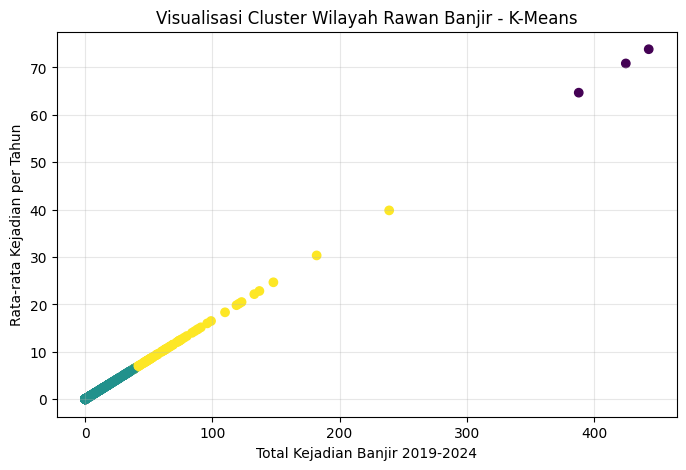

In [76]:
# Visualisasi K-Means
plt.figure(figsize=(8, 5))
plt.scatter(
    df_model["total_kejadian_2019_2024"],
    df_model["rata_rata_kejadian_tahunan"],
    c=df_model["cluster_kmeans"]
)
plt.title("Visualisasi Cluster Wilayah Rawan Banjir - K-Means")
plt.xlabel("Total Kejadian Banjir 2019-2024")
plt.ylabel("Rata-rata Kejadian per Tahun")
plt.grid(True, alpha=0.3)
plt.show()

**10. Visualisasi Hasil Clustering Agglomerative**

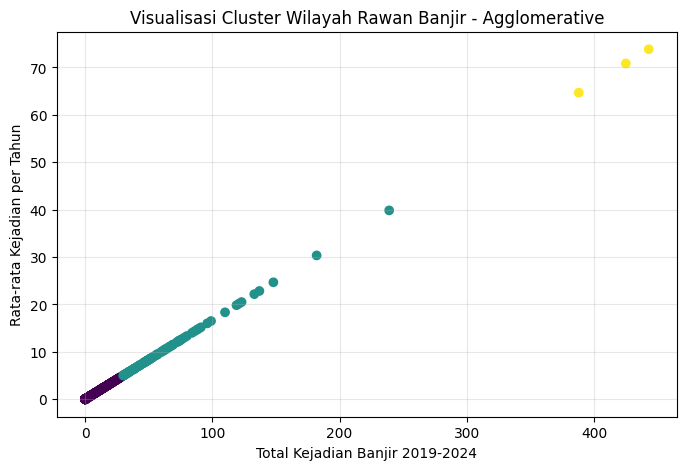

In [77]:
# Visualisasi Agglomerative
plt.figure(figsize=(8, 5))
plt.scatter(
    df_model["total_kejadian_2019_2024"],
    df_model["rata_rata_kejadian_tahunan"],
    c=df_model["cluster_agg"]
)
plt.title("Visualisasi Cluster Wilayah Rawan Banjir - Agglomerative")
plt.xlabel("Total Kejadian Banjir 2019-2024")
plt.ylabel("Rata-rata Kejadian per Tahun")
plt.grid(True, alpha=0.3)
plt.show()

**11. Visualisasi Hasil Clustering DBSCAN**

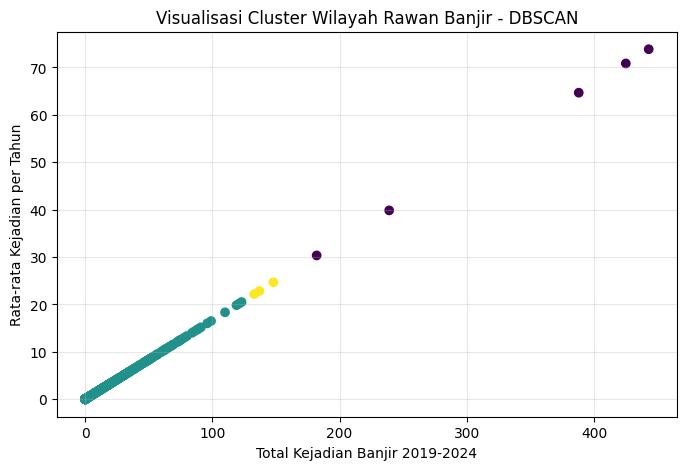

In [78]:
# Visualisasi DBSCAN
plt.figure(figsize=(8, 5))
plt.scatter(
    df_model["total_kejadian_2019_2024"],
    df_model["rata_rata_kejadian_tahunan"],
    c=df_model["cluster_dbscan"]
)
plt.title("Visualisasi Cluster Wilayah Rawan Banjir - DBSCAN")
plt.xlabel("Total Kejadian Banjir 2019-2024")
plt.ylabel("Rata-rata Kejadian per Tahun")
plt.grid(True, alpha=0.3)
plt.show()

**Interpretasi Hasil**

Hasil clustering menunjukkan bahwa wilayah kecamatan di Provinsi Jawa Barat dapat
dikelompokkan menjadi tiga kategori tingkat kerawanan banjir, yaitu rendah, sedang, dan
tinggi. Kategori rendah menunjukkan wilayah dengan kejadian banjir relatif kecil, kategori
sedang menunjukkan wilayah dengan intensitas banjir menengah, dan kategori tinggi
menunjukkan wilayah dengan kejadian banjir paling besar. Visualisasi cluster menunjukkan
adanya perbedaan yang cukup jelas antar kelompok tersebut.

**12. Menjalankan Model dan Melihat Hasilnya**

In [79]:
# Melihat model dan hasilnya
hasil_cluster = df_model[[
    "bps_nama_kabupaten_kota",
    "bps_nama_kecamatan",
    "total_kejadian_2019_2024",
    "rata_rata_kejadian_tahunan",
    "maksimum_kejadian_1_tahun",
    "cluster_kmeans",
    "label_kmeans",
    "cluster_agg",
    "label_agg",
    "cluster_dbscan",
    "label_dbscan"
]].copy()

hasil_cluster.head(10)

,bps_nama_kabupaten_kota,bps_nama_kecamatan,total_kejadian_2019_2024,rata_rata_kejadian_tahunan,maksimum_kejadian_1_tahun,cluster_kmeans,label_kmeans,cluster_agg,label_agg,cluster_dbscan,label_dbscan
0,KABUPATEN BANDUNG,ARJASARI,19,3.166667,8,1,Sedang,0,Rendah,0,Rendah
1,KABUPATEN BANDUNG,BALEENDAH,18,3.000000,3,1,Sedang,0,Rendah,0,Rendah
2,KABUPATEN BANDUNG,BANJARAN,63,10.500000,17,2,Tinggi,1,Sedang,0,Rendah
3,KABUPATEN BANDUNG,BOJONGSOANG,46,7.666667,11,2,Tinggi,1,Sedang,0,Rendah
4,KABUPATEN BANDUNG,CANGKUANG,20,3.333333,5,1,Sedang,0,Rendah,0,Rendah
5,KABUPATEN BANDUNG,CICALENGKA,30,5.000000,8,1,Sedang,1,Sedang,0,Rendah
6,KABUPATEN BANDUNG,CIKANCUNG,38,6.333333,11,1,Sedang,1,Sedang,0,Rendah
7,KABUPATEN BANDUNG,CILENGKRANG,5,0.833333,3,1,Sedang,0,Rendah,0,Rendah
8,KABUPATEN BANDUNG,CILEUNYI,50,8.333333,11,2,Tinggi,1,Sedang,0,Rendah
9,KABUPATEN BANDUNG,CIMAUNG,0,0.000000,0,1,Sedang,0,Rendah,0,Rendah


**13. Menyimpan Hasil Akhir**

In [44]:
# Menyimpan hasil
hasil_cluster.to_csv("hasil_cluster_banjir_uts.csv", index=False)
print("File berhasil disimpan sebagai: hasil_cluster_banjir_uts.csv")

File berhasil disimpan sebagai: hasil_cluster_banjir_uts.csv


In [45]:
from google.colab import files
files.download("hasil_cluster_banjir_uts.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**BAGIAN E - Model Terbaik**

Model terbaik dipilih berdasarkan Silhouette Score tertinggi serta kemudahan interpretasi hasil cluster. Untuk melakukan deployment aplikasi, model terbaik yang dipakai adalah K-Means karena:
*   Memiliki nilai evaluasi yang baik
*   Menghasilkan 3 cluster yang mudah di pahami
*   Mendukung prediksi data baru melalu centroid

In [80]:
# Perbandiangn Model Terbaik
best_model_name = comparison.iloc[0, 0]
print("Model terbaik berdasarkan perbandingan saat ini:", best_model_name)
comparison

Model terbaik berdasarkan perbandingan saat ini: DBSCAN


,Algoritma,Silhouette Score,Davies-Bouldin Score,Jumlah Cluster,Jumlah Noise
0,DBSCAN,0.7880,0.2154,2,5
1,K-Means,0.7109,0.5157,3,0
2,Agglomerative,0.6782,0.5389,3,0


NOTE:

Berdasarkan hasil evaluasi, DBSCAN memperoleh nilai Silhouette Score tertinggi yaitu 0.7880 , diikuti oleh K-Means sebesar 0.7109 dan Agglomerative Clustering sebesar 0.6782 . Namun pemilihan model terbaik tidak hanya didasarkan pada nilai Silhouette Score, tetapi juga pada kesesuaian hasil cluster dengan tujuan analisis. Dalam penelitian ini, tujuan utamanya adalah mengelompokkan wilayah menjadi tiga kategori kerawanan banjir , yaitu rendah, sedang, dan tinggi . Oleh karena itu, K-Means dipilih sebagai model terbaik karena mampu menghasilkan tiga cluster yang jelas , tidak menghasilkan noise data, dan lebih mudah digunakan untuk prediksi data baru pada aplikasi

**BAGIAN E - Insight Hasil**
*   Rendah: kecamatan dengan total, rata-rata dan maksimum kejadian banjir paling kecil
*   Sedang: kecamatan dengan integritas kejadian banjir menengah
*   Tinggi: kecamatan dengan frekuensi atau intensitas banjir paling tinggi
*   Noise atau Outlier (DBSCAN): kecamatan yang pola datanya sangat berbeda dari cluster mayoritas, sehingga tidak dimasukkan ke kelompok umum








**BAGIAN E - Analisi Smart City**

(1) Bagaimana model ini membantu pengambilan keputusan pemerintah?

Model membantu pemerintah memetakan kecamatan dengan tingkat kerawanan banjir rendah, sedang, dan tinggi sehingga prioritas mitigasi, normalisasi drainase, edukasi warga, dan alokasi anggaran dapat lebih tepat sasaran

(2) Apa risiko jika model digunakan tanpa evaluaasi lanjutan?

Risiko utamanya adalah salah interpretasi clluster, bias kebijakan, dan keputusan yang tidak sesuai kondisi lapangan. Karena itu hasil clustering harus divalidasi dengan data terbaru dan pengetahuan domain.

(3) Bagaimana menjaga etika dan privasi data warga?

Data yang digunakan sebaiknya tetap pda level agregat wilayah, tidakk memuat identitas personal warga, serta hannya digunakan untuk kepentingan pelayanan publik dan mitigasi bencana

**BAGIAN F - Deployment Aplikasi (gradio)**

Note: Agglomerative dan DBSCAN dipakai untuk perbandingan model, sedangkan deployment menggunakan K-Means karena dapat memprediksi data baru secara langsung

In [47]:
# Jika gradio belum tersedia, jalankan instalasi berikut
# !pip install -q gradio

import gradio as gr

In [81]:
def clustering_kerawanan(nama_kecamatan, total_kejadian, rata_rata_tahunan, maksimum_1_tahun):

    input_df = pd.DataFrame([[
        total_kejadian,
        rata_rata_tahunan,
        maksimum_1_tahun
    ]], columns=feature_cols)

    input_scaled = scaler.transform(input_df)
    pred_cluster = int(kmeans.predict(input_scaled)[0])
    pred_label = label_map_kmeans[pred_cluster]

    if pred_label == "Rendah":
        keterangan = "Wilayah cenderung memiliki intensitas banjir rendah."
    elif pred_label == "Sedang":
        keterangan = "Wilayah memiliki tingkat kerawanan banjir menengah."
    else:
        keterangan = "Wilayah termasuk kategori rawan banjir tinggi dan perlu prioritas mitigasi."

    return f"""
### Hasil Clustering

Nama Kecamatan : **{nama_kecamatan}**

Cluster K-Means : **{pred_cluster}**

Kategori Kerawanan : **{pred_label}**

Penjelasan :
{keterangan}
"""

demo = gr.Interface(
    fn=clustering_kerawanan,
    inputs=[
        gr.Textbox(label="Nama Kecamatan"),
        gr.Number(label="Total Kejadian Banjir 2019-2024"),
        gr.Number(label="Rata-rata Kejadian per Tahun"),
        gr.Number(label="Maksimum Kejadian dalam 1 Tahun"),
    ],
    outputs=gr.Markdown(label="Hasil Clustering"),
    title="Aplikasi Clustering Tingkat Kerawanan Banjir Kecamatan",
    description="Masukkan tiga fitur utama untuk melihat hasil clustering tingkat kerawanan banjir kecamatan menggunakan algoritma K-Means."
)

In [49]:
# Jalankan aplikasi
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://97f5b283f1b3c6166d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Screenshot Aplikasi nya**

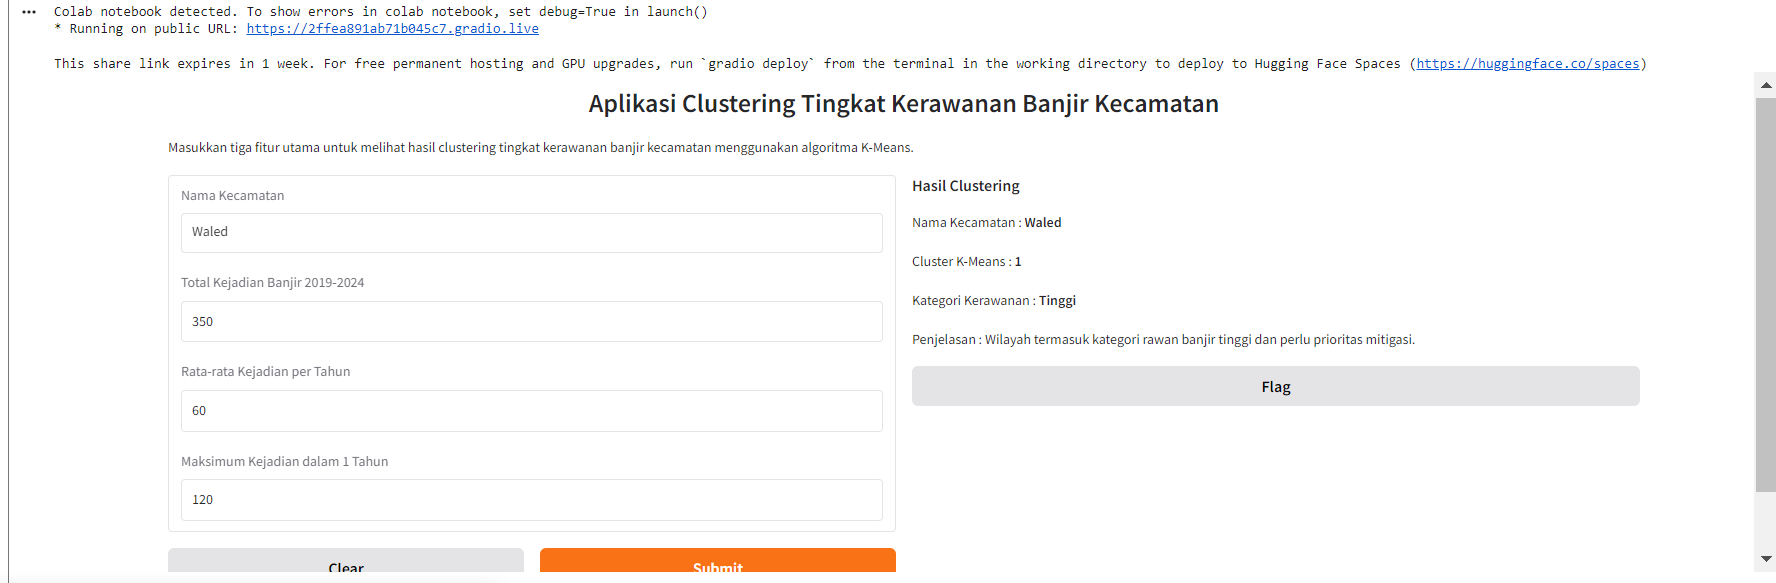